# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

In [2]:
df = pd.read_csv("../data/am_pm.csv")
df.head()

,date,am,pm,target,target_bin,predict
0,2020-04-17,21,2,working_day,0,1
1,2020-04-18,1,68,weekend,1,0
2,2020-04-19,18,15,weekend,1,0
3,2020-04-20,2,23,working_day,0,0
4,2020-04-21,0,25,working_day,0,0


In [3]:
df['target_bin'] = df['target'].map({'working_day': 0, 'weekend': 1})
X = df[['am', 'pm']]
y = df['target_bin']
model = LogisticRegression(fit_intercept=False, random_state=21)
model.fit(X, y)
df['predict'] = model.predict(X)

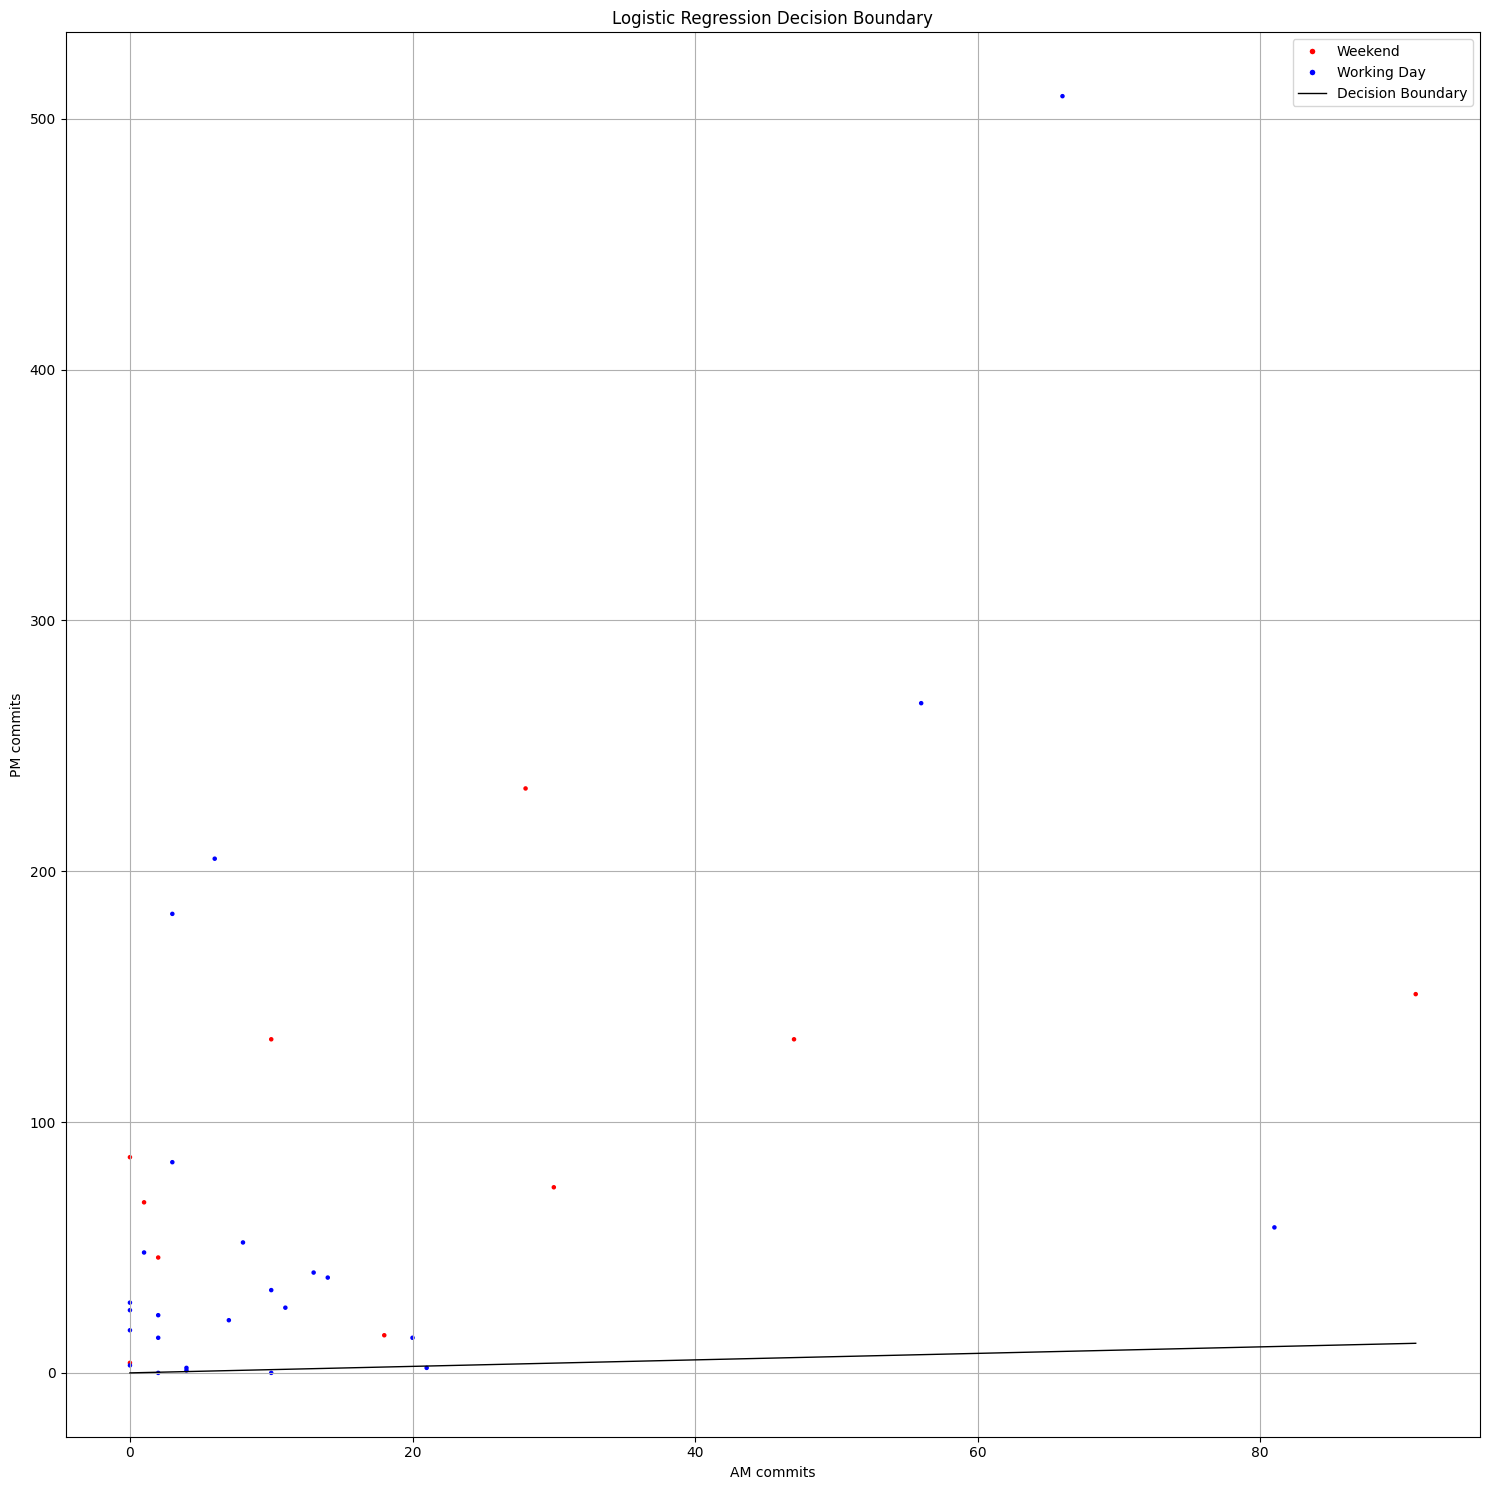

In [4]:
colors = df['target'].map({'weekend': 'red', 'working_day': 'blue'})

plt.figure(figsize=(15, 15))
plt.scatter(df['am'], df['pm'], c=colors, label='Data points', s=5)

w1, w2 = model.coef_[0]
x_vals = np.linspace(df['am'].min(), df['am'].max(), 2)
y_vals = - (w1 / w2) * x_vals
plt.plot(x_vals, y_vals, color='black', linestyle='-', label='Decision Boundary', lw=1)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Weekend', markerfacecolor='red', markersize=5),
    Line2D([0], [0], marker='o', color='w', label='Working Day', markerfacecolor='blue', markersize=5),
    Line2D([0], [0], color='black', lw=1, linestyle='-', label='Decision Boundary')
]

plt.legend(handles=legend_elements)
plt.xlabel('AM commits')
plt.ylabel('PM commits')
plt.title('Logistic Regression Decision Boundary')
plt.grid(True)
plt.tight_layout()
plt.show()


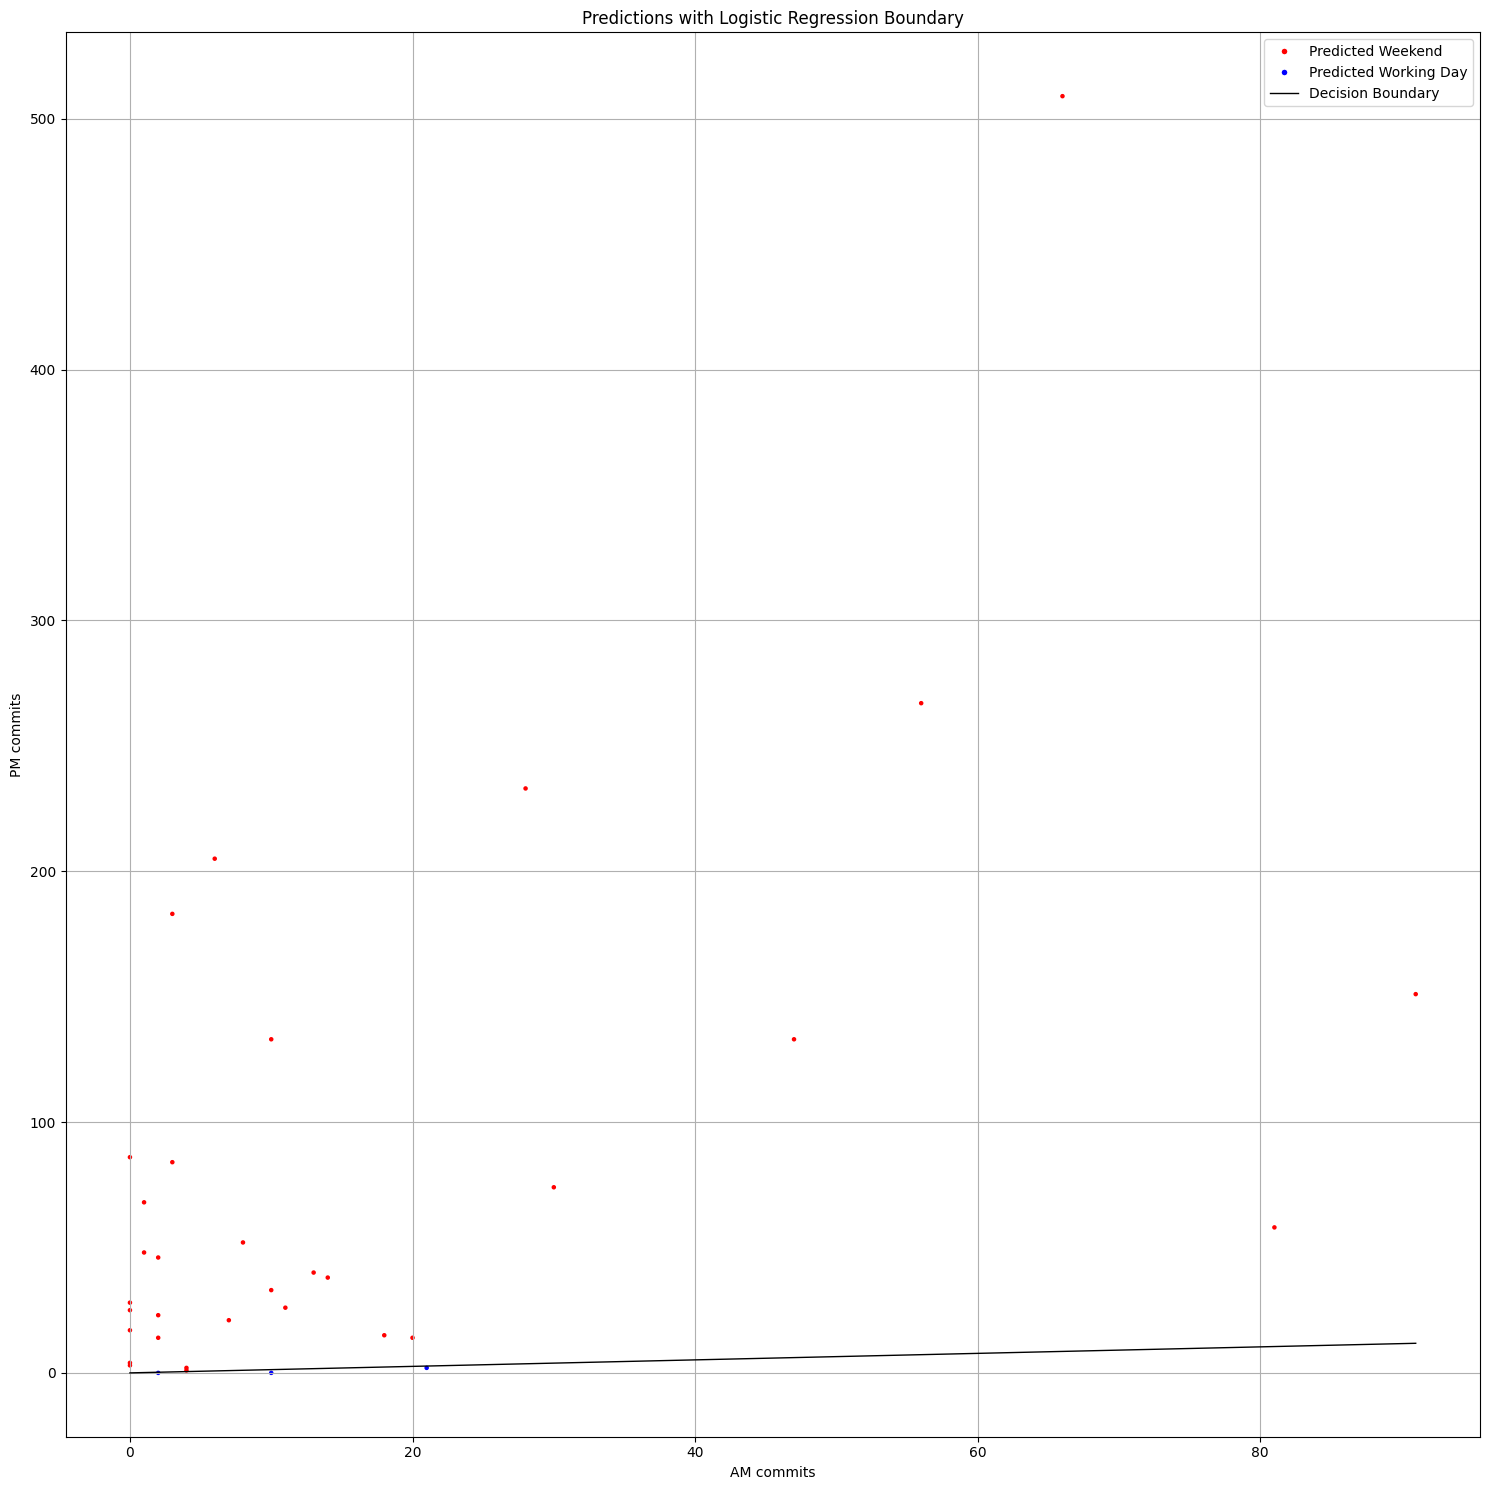

In [5]:
colors = df['predict'].map({0: 'red', 1: 'blue'})

plt.figure(figsize=(15, 15))
plt.scatter(df['am'], df['pm'], c=colors, label='Predicted', s=5)
plt.plot(x_vals, y_vals, color='black', linestyle='-', label='Decision Boundary', lw=1)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Predicted Weekend', markerfacecolor='red', markersize=5),
    Line2D([0], [0], marker='o', color='w', label='Predicted Working Day', markerfacecolor='blue', markersize=5),
    Line2D([0], [0], color='black', lw=1, linestyle='-', label='Decision Boundary')
]

plt.legend(handles=legend_elements)
plt.xlabel('AM commits')
plt.ylabel('PM commits')
plt.title('Predictions with Logistic Regression Boundary')
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(fit_intercept=False, random_state=21)
model.fit(X_scaled, y)
df['predict'] = model.predict(X_scaled)

acc = accuracy_score(df['predict'], y)
print(acc)

0.7428571428571429


In [7]:
df.head(35)

,date,am,pm,target,target_bin,predict
0,2020-04-17,21,2,working_day,0,0
1,2020-04-18,1,68,weekend,1,0
2,2020-04-19,18,15,weekend,1,0
3,2020-04-20,2,23,working_day,0,0
4,2020-04-21,0,25,working_day,0,0
5,2020-04-22,0,28,working_day,0,0
6,2020-04-23,10,33,working_day,0,0
7,2020-04-24,2,14,working_day,0,0
8,2020-04-25,30,74,weekend,1,1
9,2020-04-26,28,233,weekend,1,1


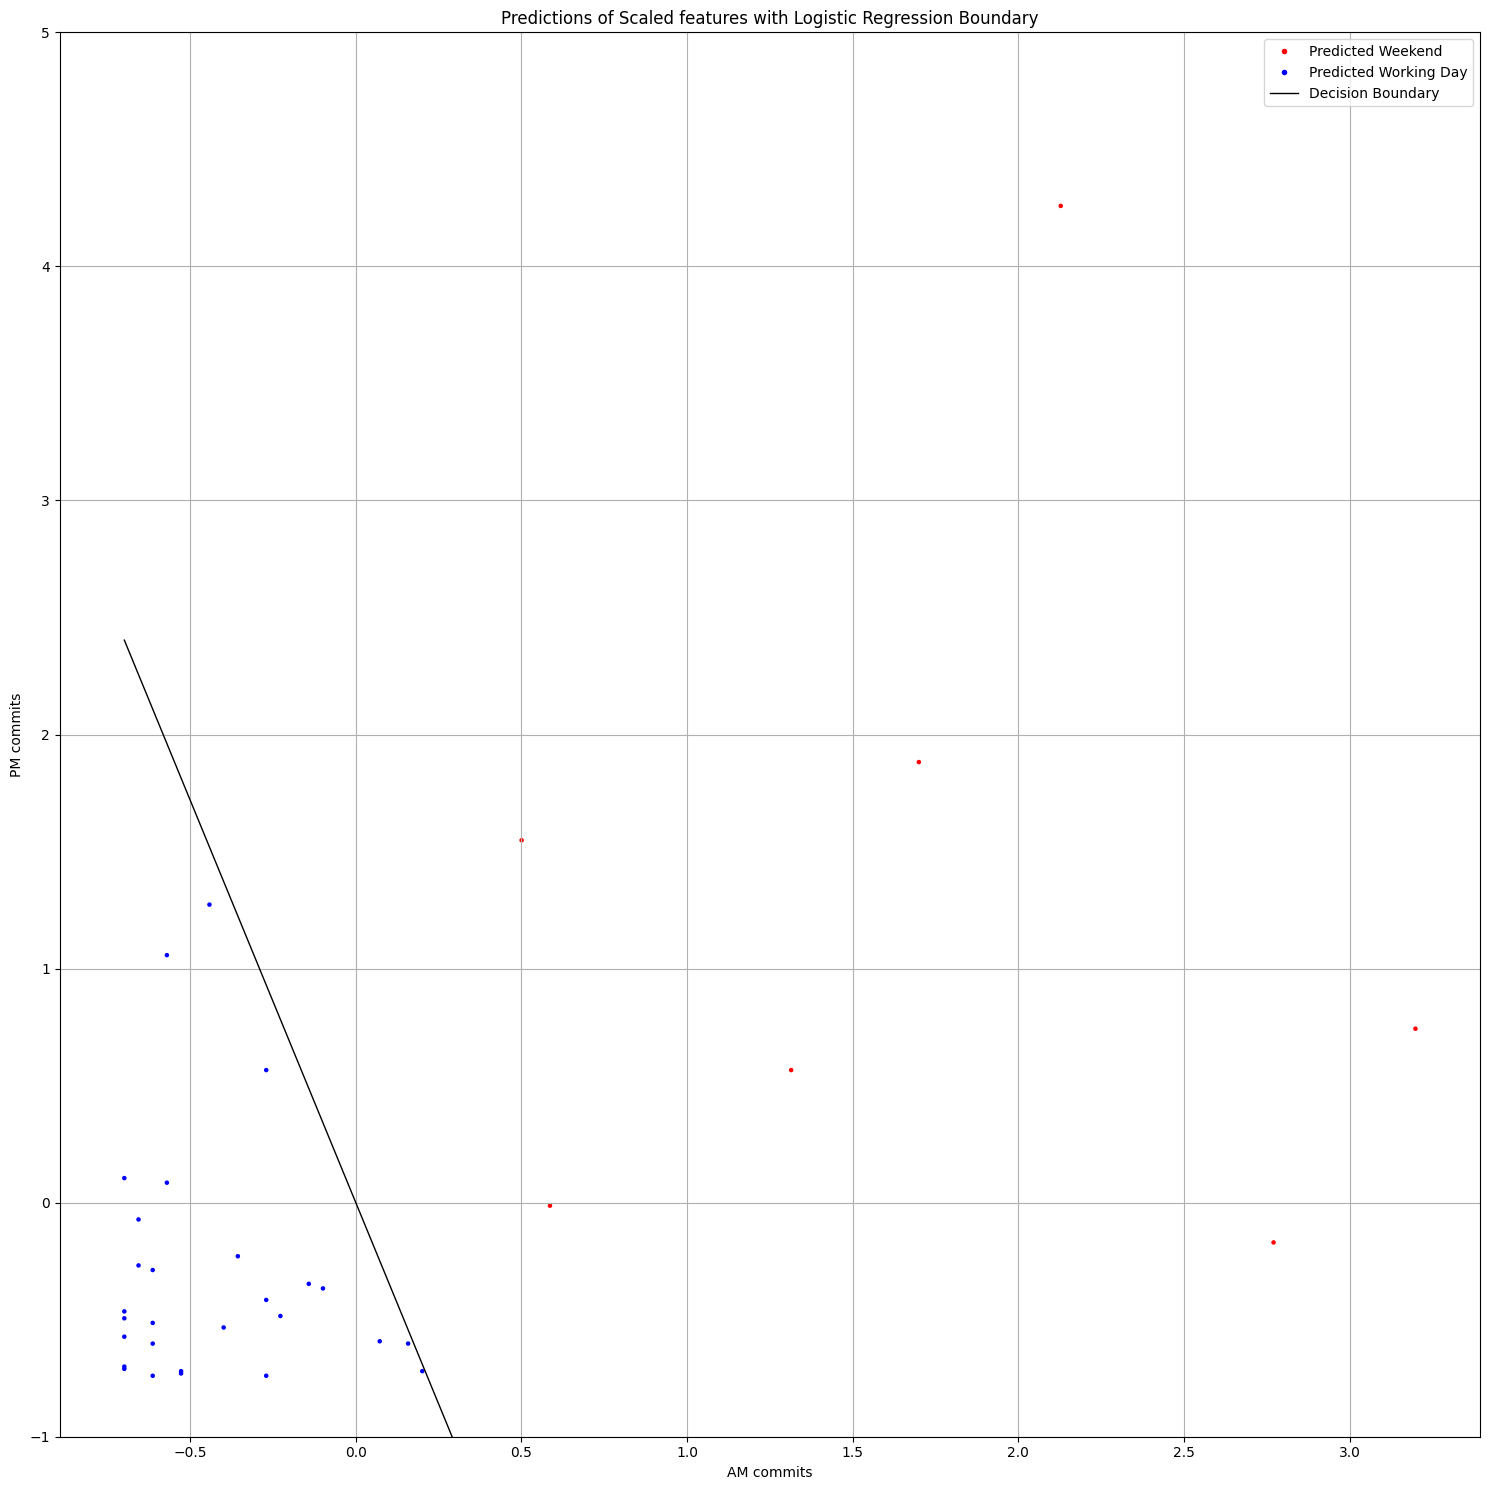

In [8]:
colors = df['predict'].map({0: 'blue', 1: 'red'})

plt.figure(figsize=(15, 15))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=colors, label='Predicted', s=5)

w1, w2 = model.coef_[0]
x_vals = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 2)
y_vals = - (w1 / w2) * x_vals
plt.plot(x_vals, y_vals, color='black', linestyle='-', label='Decision Boundary', lw=1)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Predicted Weekend', markerfacecolor='red', markersize=5),
    Line2D([0], [0], marker='o', color='w', label='Predicted Working Day', markerfacecolor='blue', markersize=5),
    Line2D([0], [0], color='black', lw=1, linestyle='-', label='Decision Boundary')
]

plt.legend(handles=legend_elements)
plt.xlabel('AM commits')
plt.ylabel('PM commits')
plt.title('Predictions of Scaled features with Logistic Regression Boundary')
plt.ylim(-1, 5)
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

In [9]:
model = SVC(probability=True, random_state=21)
model.fit(X_scaled, y)
df['predict'] = model.predict(X_scaled)

acc = accuracy_score(df['predict'], y)
print(acc)

0.7428571428571429


In [10]:
model = SVC(probability=True, random_state=21, kernel='poly')
model.fit(X_scaled, y)
df['predict'] = model.predict(X_scaled)

acc = accuracy_score(df['predict'], y)
print(f"SVC_poly_kernel:", acc)

model = SVC(probability=True, random_state=21, kernel='rbf')
model.fit(X_scaled, y)
df['predict'] = model.predict(X_scaled)

acc = accuracy_score(df['predict'], y)
print(f"SVC_rbf_kernel:", acc)

model = SVC(probability=True, random_state=21, kernel='sigmoid')
model.fit(X_scaled, y)
df['predict'] = model.predict(X_scaled)

acc = accuracy_score(df['predict'], y)
print(f"SVC_sigmoid_kernel:", acc)

model_linear = SVC(probability=True, random_state=21, kernel='linear')
model_linear.fit(X_scaled, y)
df['predict'] = model_linear.predict(X_scaled)

acc = accuracy_score(df['predict'], y)
print(f"SVC_linear_kernel:", acc)

SVC_poly_kernel: 0.7428571428571429
SVC_rbf_kernel: 0.7428571428571429
SVC_sigmoid_kernel: 0.6857142857142857
SVC_linear_kernel: 0.7142857142857143


In [11]:
df.head(35)

,date,am,pm,target,target_bin,predict
0,2020-04-17,21,2,working_day,0,0
1,2020-04-18,1,68,weekend,1,0
2,2020-04-19,18,15,weekend,1,0
3,2020-04-20,2,23,working_day,0,0
4,2020-04-21,0,25,working_day,0,0
5,2020-04-22,0,28,working_day,0,0
6,2020-04-23,10,33,working_day,0,0
7,2020-04-24,2,14,working_day,0,0
8,2020-04-25,30,74,weekend,1,0
9,2020-04-26,28,233,weekend,1,0


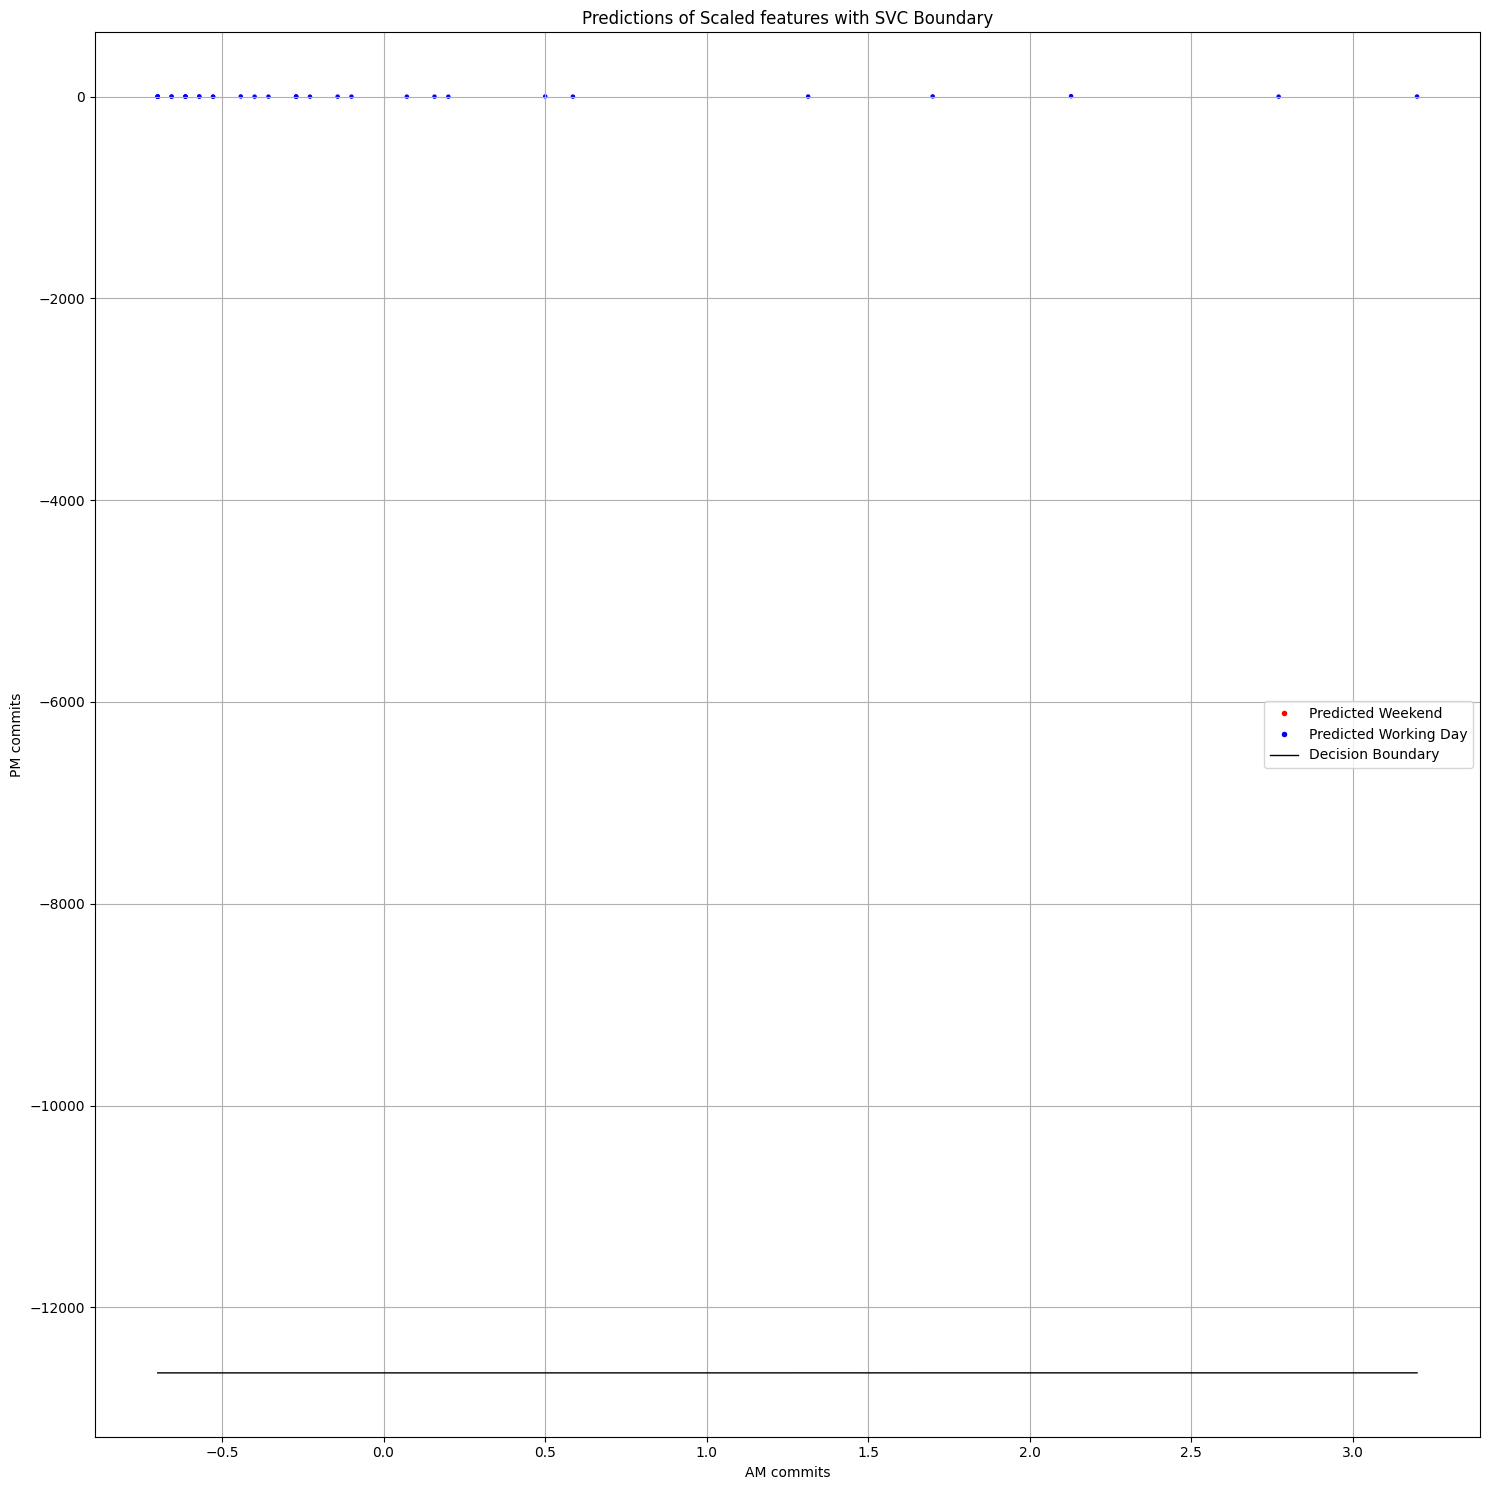

In [12]:
colors = df['predict'].map({0: 'blue', 1: 'red'})

plt.figure(figsize=(15, 15))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=colors, label='Predicted', s=5)

w1, w2 = model_linear.coef_[0]
b = model_linear.intercept_[0]

x_vals = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 2)
y_vals = - (w1 / w2) * x_vals - (b / w2)

plt.plot(x_vals, y_vals, color='black', linestyle='-', label='Decision Boundary', lw=1)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Predicted Weekend', markerfacecolor='red', markersize=5),
    Line2D([0], [0], marker='o', color='w', label='Predicted Working Day', markerfacecolor='blue', markersize=5),
    Line2D([0], [0], color='black', lw=1, linestyle='-', label='Decision Boundary')
]

plt.legend(handles=legend_elements)
plt.xlabel('AM commits')
plt.ylabel('PM commits')
plt.title('Predictions of Scaled features with SVC Boundary')
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

In [13]:
model_depth4 = DecisionTreeClassifier(max_depth=4, random_state=42)
model_depth4.fit(X_scaled, y)
df['predict4'] = model_depth4.predict(X_scaled)

acc = accuracy_score(df['predict4'], y)
print(acc)

0.9428571428571428


In [14]:
model = DecisionTreeClassifier(max_depth=1, random_state=42)
model.fit(X_scaled, y)
df['predict'] = model.predict(X_scaled)

acc = accuracy_score(df['predict'], y)
print(f"Tree_acc_depth1:", acc)

model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(X_scaled, y)
df['predict'] = model.predict(X_scaled)

acc = accuracy_score(df['predict'], y)
print(f"Tree_acc_depth2:", acc)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_scaled, y)
df['predict'] = model.predict(X_scaled)

acc = accuracy_score(df['predict'], y)
print(f"Tree_acc_depth3:", acc)

Tree_acc_depth1: 0.7714285714285715
Tree_acc_depth2: 0.8571428571428571
Tree_acc_depth3: 0.8857142857142857


In [15]:
df.head(35)

,date,am,pm,target,target_bin,predict,predict4
0,2020-04-17,21,2,working_day,0,0,0
1,2020-04-18,1,68,weekend,1,1,1
2,2020-04-19,18,15,weekend,1,0,0
3,2020-04-20,2,23,working_day,0,0,0
4,2020-04-21,0,25,working_day,0,0,0
5,2020-04-22,0,28,working_day,0,0,0
6,2020-04-23,10,33,working_day,0,0,0
7,2020-04-24,2,14,working_day,0,0,0
8,2020-04-25,30,74,weekend,1,1,1
9,2020-04-26,28,233,weekend,1,0,1


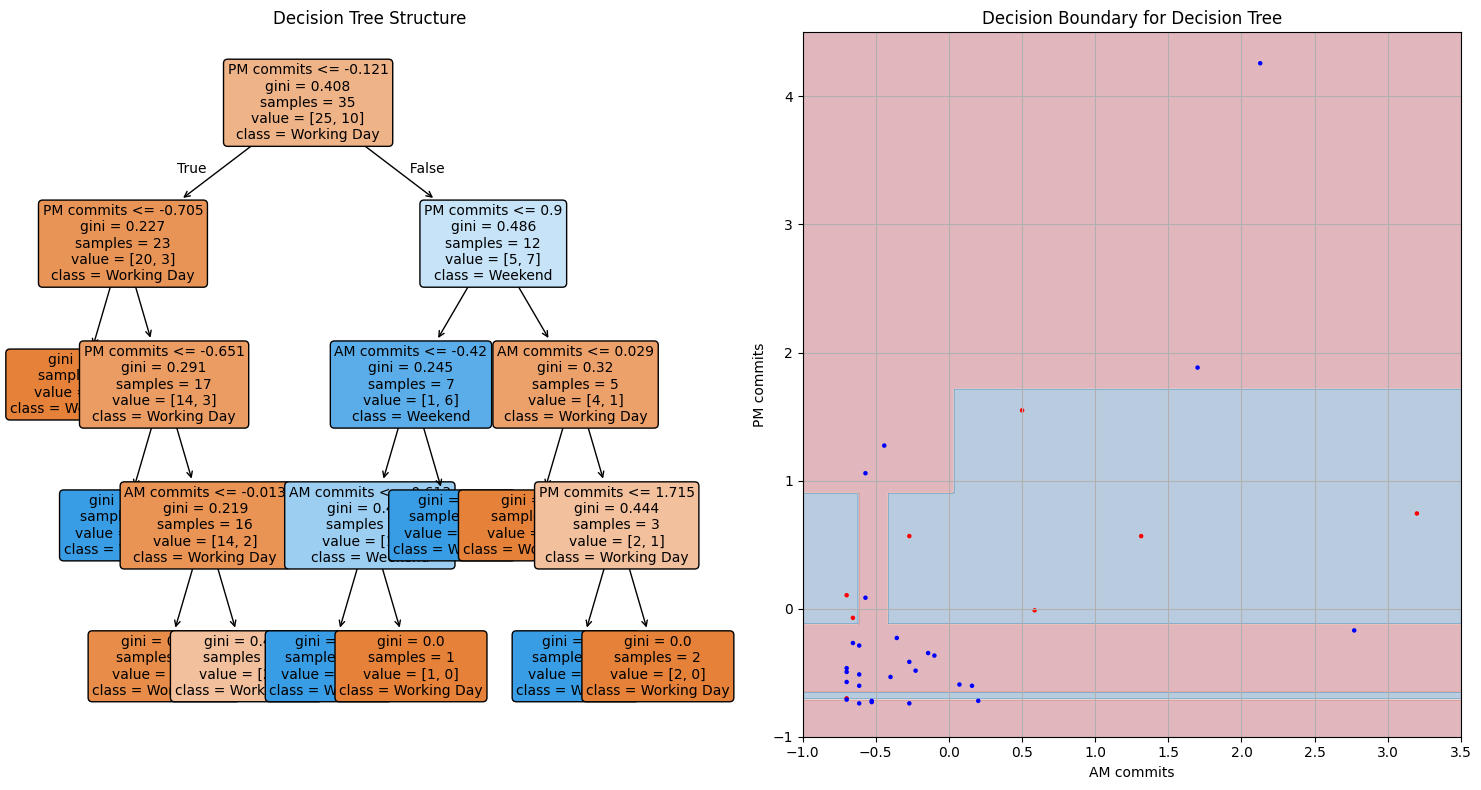

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(15, 8))

plot_tree(model_depth4, 
          feature_names=['AM commits', 'PM commits'],
          class_names=['Working Day', 'Weekend'],
          filled=True,
          rounded=True,
          fontsize=10,
          ax=axs[0])
axs[0].set_title('Decision Tree Structure')

x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

Z = model_depth4.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

colors = df['predict4'].map({0: 'blue', 1: 'red'})

axs[1].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
axs[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=colors, s=5)
axs[1].set_xlabel('AM commits')
axs[1].set_ylabel('PM commits')
axs[1].set_title('Decision Boundary for Decision Tree')
axs[1].grid(True)

plt.xlim(-1, 3.5)
plt.ylim(-1, 4.5)
plt.tight_layout()
plt.show()


4